In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("Using:", gpus)

Using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load from local path directly
import pickle
import os

def load_cifar10_local(path):
    def load_batch(file):
        with open(file, 'rb') as f:
            d = pickle.load(f, encoding='bytes')
        return d[b'data'], d[b'labels']

    # Training batches
    x_train, y_train = [], []
    for i in range(1, 6):
        data, labels = load_batch(os.path.join(path, f'data_batch_{i}'))
        x_train.append(data)
        y_train.extend(labels)

    x_train = np.concatenate(x_train)
    y_train = np.array(y_train)

    # Test batch
    x_test, y_test = load_batch(os.path.join(path, 'test_batch'))
    y_test = np.array(y_test)

    # Reshape to (N, 32, 32, 3)
    x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    x_test  = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return (x_train, y_train), (x_test, y_test)

# Your local path
LOCAL_PATH = r"C:\Users\Nikhil\.keras\datasets\cifar-10-batches-py"

(x_train, y_train), (x_test, y_test) = load_cifar10_local(LOCAL_PATH)

# Normalize
x_train = x_train / 255.0
x_test  = x_test  / 255.0

class_names = ['airplane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print("Dataset loaded from local!")
print(f"Training: {x_train.shape}")
print(f"Testing : {x_test.shape}")

Dataset loaded from local!
Training: (50000, 32, 32, 3)
Testing : (10000, 32, 32, 3)


In [8]:
# Prepare labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

# LeeNet Implementation

In [2]:
# LeNet Architecture
lenet_model = Sequential([
    # Layer 1 - First Convolution
    Conv2D(6, (5,5), activation='relu', padding='same', input_shape=(32,32,3)),
    AveragePooling2D((2,2)),

    # Layer 2 - Second Convolution
    Conv2D(16, (5,5), activation='relu'),
    AveragePooling2D((2,2)),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(120, activation='relu'),
    Dense(84,  activation='relu'),
    Dense(10,  activation='softmax')
], name='LeNet')

lenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lenet_model.summary()

D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
print("Training LeNet...")
start_time = time.time()

history_lenet = lenet_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

train_time = time.time() - start_time
print(f"Training Complete! Time: {train_time:.2f} seconds")

Training LeNet...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.3986 - loss: 1.6612 - val_accuracy: 0.4797 - val_loss: 1.4330
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5097 - loss: 1.3732 - val_accuracy: 0.5339 - val_loss: 1.2971
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5500 - loss: 1.2575 - val_accuracy: 0.5557 - val_loss: 1.2549
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.5792 - loss: 1.1774 - val_accuracy: 0.5763 - val_loss: 1.1923
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6025 - loss: 1.1087 - val_accuracy: 0.5773 - val_loss: 1.2023
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6206 - loss: 1.0628 - val_accuracy: 0.6010 - val_loss: 1.1208
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.6366 - loss: 1.0177 - val_accuracy: 0.6034 - val_loss: 1.1143
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6552

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred_prob  = lenet_model.predict(x_test, verbose=0)
y_pred_lenet = np.argmax(y_pred_prob, axis=1)

lenet_accuracy  = accuracy_score(y_test, y_pred_lenet) * 100
lenet_precision = precision_score(y_test, y_pred_lenet, average='macro') * 100
lenet_recall    = recall_score(y_test, y_pred_lenet, average='macro') * 100

print("=" * 40)
print("LENET RESULTS:")
print("=" * 40)
print(f"Accuracy  : {lenet_accuracy:.2f}%")
print(f"Precision : {lenet_precision:.2f}%")
print(f"Recall    : {lenet_recall:.2f}%")
print("=" * 40)

LENET RESULTS:
Accuracy  : 61.05%
Precision : 61.44%
Recall    : 61.05%


# AlexNet Implementation

In [4]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

# Reduced AlexNet - same concept, faster training
alexnet_model = Sequential([
    Conv2D(64,  (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(1024, activation='relu'),  # 4096 se 1024 kiya
    Dropout(0.5),
    Dense(512,  activation='relu'),  # 4096 se 512 kiya
    Dropout(0.5),
    Dense(10,   activation='softmax')
], name='AlexNet')

alexnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

alexnet_model.summary()

D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,096,842 (19.44 MB)

 Trainable params: 5,096,458 (19.44 MB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
print("Training AlexNet...")
start_time = time.time()

history_alexnet = alexnet_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

train_time = time.time() - start_time
print(f"Training Complete! Time: {train_time:.2f} seconds")

Training AlexNet...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 275s 330ms/step - accuracy: 0.4749 - loss: 1.4775 - val_accuracy: 0.5606 - val_loss: 1.2480
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 195s 249ms/step - accuracy: 0.6295 - loss: 1.0676 - val_accuracy: 0.6311 - val_loss: 1.0773
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 198s 253ms/step - accuracy: 0.6850 - loss: 0.9115 - val_accuracy: 0.6330 - val_loss: 1.0595
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 198s 248ms/step - accuracy: 0.7249 - loss: 0.8113 - val_accuracy: 0.6791 - val_loss: 0.9600
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 196s 250ms/step - accuracy: 0.7541 - loss: 0.7234 - val_accuracy: 0.7076 - val_loss: 0.8554
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 191s 244ms/step - accuracy: 0.7735 - loss: 0.6609 - val_accuracy: 0.6649 - val_loss: 1.0003
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 255ms/step - accuracy: 0.7977 - loss: 0.5976 - val_accuracy: 0.6796 - val_loss: 0.9635
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 254ms/step 

In [13]:
y_pred_prob    = alexnet_model.predict(x_test, verbose=0)
y_pred_alexnet = np.argmax(y_pred_prob, axis=1)

alexnet_accuracy  = accuracy_score(y_test, y_pred_alexnet) * 100
alexnet_precision = precision_score(y_test, y_pred_alexnet, average='macro') * 100
alexnet_recall    = recall_score(y_test, y_pred_alexnet, average='macro') * 100

print("=" * 40)
print("ALEXNET RESULTS:")
print("=" * 40)
print(f"Accuracy  : {alexnet_accuracy:.2f}%")
print(f"Precision : {alexnet_precision:.2f}%")
print(f"Recall    : {alexnet_recall:.2f}%")
print("=" * 40)

ALEXNET RESULTS:
Accuracy  : 73.99%
Precision : 75.17%
Recall    : 73.99%


# VGG16 Implementation

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

vgg16_model = Sequential([
    # Block 1
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10,  activation='softmax')
], name='VGG16')

vgg16_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16_model.summary()

Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,380,554 (12.90 MB)

 Trainable params: 3,378,762 (12.89 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [17]:
print("Training VGG16..")
start_time = time.time()

history_vgg16 = vgg16_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(x_test,y_test_cat),
    verbose=1
)

train_time = time.time() - start_time
print(f"Training Complete! Time: {train_time:.2f} seconds")

Training VGG16..
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1311s 2s/step - accuracy: 0.3878 - loss: 1.7261 - val_accuracy: 0.5548 - val_loss: 1.3076
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1366s 2s/step - accuracy: 0.5980 - loss: 1.1745 - val_accuracy: 0.5836 - val_loss: 1.2137
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1393s 2s/step - accuracy: 0.6888 - loss: 0.9349 - val_accuracy: 0.7169 - val_loss: 0.8660
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1142s 1s/step - accuracy: 0.7407 - loss: 0.7960 - val_accuracy: 0.7426 - val_loss: 0.8053
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1237s 2s/step - accuracy: 0.7800 - loss: 0.6870 - val_accuracy: 0.7469 - val_loss: 0.7440
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1308s 2s/step - accuracy: 0.8139 - loss: 0.5840 - val_accuracy: 0.7758 - val_loss: 0.7096
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1367s 2s/step - accuracy: 0.8393 - loss: 0.5051 - val_accuracy: 0.7674 - val_loss: 0.7327
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 1290s 2s/step - accuracy: 0.8635 

In [20]:
y_pred_prob    = vgg16_model.predict(x_test, verbose=0)
y_pred_vgg16 = np.argmax(y_pred_prob, axis=1)

vgg16_accuracy  = accuracy_score(y_test, y_pred_vgg16) * 100
vgg16_precision = precision_score(y_test, y_pred_vgg16, average='macro') * 100
vgg16_recall    = recall_score(y_test, y_pred_vgg16, average='macro') * 100

print("=" * 40)
print("VGG16 RESULTS:")
print("=" * 40)
print(f"Accuracy  : {vgg16_accuracy:.2f}%")
print(f"Precision : {vgg16_precision:.2f}%")
print(f"Recall    : {vgg16_recall:.2f}%")
print("=" * 40)

VGG16 RESULTS:
Accuracy  : 78.81%
Precision : 81.72%
Recall    : 78.81%


# ResNet50 Implementation

In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import time

# Load pre-trained ResNet50
base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)
base_resnet.trainable = False

# Add custom head
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output, name='ResNet50')

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ResNet50...")
start_time = time.time()

history_resnet = resnet_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

print(f"Training Complete! Time: {time.time()-start_time:.2f} seconds")

y_pred_prob     = resnet_model.predict(x_test, verbose=0)
y_pred_resnet   = np.argmax(y_pred_prob, axis=1)

resnet_accuracy  = accuracy_score(y_test, y_pred_resnet) * 100
resnet_precision = precision_score(y_test, y_pred_resnet, average='macro') * 100
resnet_recall    = recall_score(y_test, y_pred_resnet, average='macro') * 100

print("=" * 40)
print("RESNET50 RESULTS:")
print("=" * 40)
print(f"Accuracy  : {resnet_accuracy:.2f}%")
print(f"Precision : {resnet_precision:.2f}%")
print(f"Recall    : {resnet_recall:.2f}%")
print("=" * 40)

resnet_model.save('resnet_cifar10.h5')
print("ResNet50 Saved!")

Training ResNet50...
Epoch 1/10
782/782 [==============================] - 89s 60ms/step - loss: 2.2663 - accuracy: 0.1327 - val_loss: 2.1762 - val_accuracy: 0.2133
Epoch 2/10
782/782 [==============================] - 41s 53ms/step - loss: 2.1851 - accuracy: 0.1650 - val_loss: 2.1104 - val_accuracy: 0.2415
Epoch 3/10
782/782 [==============================] - 40s 51ms/step - loss: 2.1477 - accuracy: 0.1846 - val_loss: 2.0343 - val_accuracy: 0.2702
Epoch 4/10
782/782 [==============================] - 46s 59ms/step - loss: 2.1285 - accuracy: 0.1967 - val_loss: 2.0259 - val_accuracy: 0.2748
Epoch 5/10
782/782 [==============================] - 47s 60ms/step - loss: 2.1135 - accuracy: 0.2017 - val_loss: 1.9840 - val_accuracy: 0.2912
Epoch 6/10
782/782 [==============================] - 50s 64ms/step - loss: 2.0953 - accuracy: 0.2085 - val_loss: 1.9560 - val_accuracy: 0.2854
Epoch 7/10
782/782 [==============================] - 48s 61ms/step - loss: 2.0902 - accuracy: 0.2101 - val_loss: 1

# YOLO Implementation

In [7]:
from ultralytics import YOLO
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import time

print("Loading YOLOv8...")
yolo_base = YOLO('yolov8n.pt')

print("Extracting features using YOLO backbone...")

def extract_yolo_features(images, model, batch_size=100):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch_uint8 = (batch * 255).astype(np.uint8)
        batch_features = []
        for img in batch_uint8:
            result = model.embed(img, verbose=False)
            if result is not None and len(result) > 0:
                feat = result[0].cpu().numpy().flatten()
                batch_features.append(feat)
            else:
                batch_features.append(np.zeros(512))
        features.extend(batch_features)
        if i % 1000 == 0:
            print(f"Processed {i}/{len(images)} images...")
    return np.array(features)

print("Extracting training features...")
X_train_yolo = extract_yolo_features(x_train[:5000], yolo_base)
X_test_yolo  = extract_yolo_features(x_test[:1000],  yolo_base)
y_train_yolo = y_train[:5000]
y_test_yolo  = y_test[:1000]

print("Training classifier...")
yolo_classifier = LogisticRegression(max_iter=1000, random_state=42)
yolo_classifier.fit(X_train_yolo, y_train_yolo)

y_pred_yolo = yolo_classifier.predict(X_test_yolo)

yolo_accuracy  = accuracy_score(y_test_yolo, y_pred_yolo) * 100
yolo_precision = precision_score(y_test_yolo, y_pred_yolo, average='macro') * 100
yolo_recall    = recall_score(y_test_yolo, y_pred_yolo, average='macro') * 100

print("=" * 40)
print("YOLO RESULTS:")
print("=" * 40)
print(f"Accuracy  : {yolo_accuracy:.2f}%")
print(f"Precision : {yolo_precision:.2f}%")
print(f"Recall    : {yolo_recall:.2f}%")
print("=" * 40)

Loading YOLOv8...
Extracting features using YOLO backbone...
Extracting training features...
Processed 0/5000 images...
Processed 1000/5000 images...
Processed 2000/5000 images...
Processed 3000/5000 images...
Processed 4000/5000 images...
Processed 0/1000 images...
Training classifier...
YOLO RESULTS:
Accuracy  : 54.60%
Precision : 53.93%
Recall    : 54.36%


# Faster-CNN

In [12]:
from tensorflow.keras.applications import VGG16 as VGG16Base
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
import time

print("Loading VGG16 backbone for Faster R-CNN...")

# VGG16 Backbone
faster_rcnn_base = VGG16Base(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(32, 32, 3)
)
print("Extracting features...")
start_time = time.time()

X_train_preprocessed = preprocess_input(x_train * 255.0)
X_test_preprocessed = preprocess_input(x_test * 255.0)

X_train_frcnn = faster_rcnn_base.predict(
    X_train_preprocessed,
    batch_size=64,
    verbose=1
)

X_test_frcnn = faster_rcnn_base.predict(
    X_test_preprocessed,
    batch_size=32,
    verbose=1
)

feature_time = time.time() - start_time
print(f"Feature extraction complete! Time: {feature_time:.2f} seconds")

print("Scaling extracted features...")

scaler = StandardScaler()

X_train_frcnn = scaler.fit_transform(X_train_frcnn)
X_test_frcnn = scaler.transform(X_test_frcnn)

# Train Logistic Regression
print("Training classifier...")

train_start = time.time()

frcnn_classifier = LogisticRegression(
    max_iter=3000,
    solver='lbfgs',
    random_state=42
)

frcnn_classifier.fit(X_train_frcnn, y_train.ravel())
training_time = time.time() - train_start
y_pred_frcnn = frcnn_classifier.predict(X_test_frcnn)

frcnn_accuracy = accuracy_score(y_test, y_pred_frcnn) * 100
frcnn_precision = precision_score(
    y_test,
    y_pred_frcnn,
    average='macro',
    zero_division=0
) * 100

frcnn_recall = recall_score(
    y_test,
    y_pred_frcnn,
    average='macro',
    zero_division=0
) * 100

print("=" * 45)
print("FASTER R-CNN RESULTS")
print("=" * 45)
print(f"Feature Extraction Time : {feature_time:.2f} seconds")
print(f"Classifier Training Time: {training_time:.2f} seconds")
print(f"Accuracy                : {frcnn_accuracy:.2f}%")
print(f"Precision               : {frcnn_precision:.2f}%")
print(f"Recall                  : {frcnn_recall:.2f}%")
print("=" * 45)

Loading VGG16 backbone for Faster R-CNN...
Extracting features...
313/313 [==============================] - 4s 10ms/step
Feature extraction complete! Time: 25.95 seconds
Scaling extracted features...
Training classifier...
FASTER R-CNN RESULTS
Feature Extraction Time : 25.95 seconds
Classifier Training Time: 13.25 seconds
Accuracy                : 66.65%
Precision               : 66.32%
Recall                  : 66.65%


# K-Means Implementation

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.stats import mode
import numpy as np
import time

print("Preparing data for K-Means...")
X_train_flat = x_train.reshape(len(x_train), -1)
X_test_flat  = x_test.reshape(len(x_test),  -1)

print("Training K-Means (10 clusters)...")
start_time = time.time()

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_train_flat)

print(f"Training Complete! Time: {time.time()-start_time:.2f}s")

# Map clusters to labels
train_clusters = kmeans.predict(X_train_flat)
cluster_to_label = {}
for cluster in range(10):
    mask = train_clusters == cluster
    if mask.sum() > 0:
        cluster_to_label[cluster] = mode(y_train[mask], keepdims=True).mode[0]
    else:
        cluster_to_label[cluster] = 0

test_clusters  = kmeans.predict(X_test_flat)
y_pred_kmeans  = np.array([cluster_to_label[c] for c in test_clusters])

kmeans_accuracy  = accuracy_score(y_test, y_pred_kmeans) * 100
kmeans_precision = precision_score(y_test, y_pred_kmeans, average='macro', zero_division=0) * 100
kmeans_recall    = recall_score(y_test, y_pred_kmeans, average='macro', zero_division=0) * 100

print("=" * 40)
print("K-MEANS RESULTS:")
print("=" * 40)
print(f"Accuracy  : {kmeans_accuracy:.2f}%")
print(f"Precision : {kmeans_precision:.2f}%")
print(f"Recall    : {kmeans_recall:.2f}%")
print("=" * 40)

Preparing data for K-Means...
Training K-Means (10 clusters)...
Training Complete! Time: 664.83s
K-MEANS RESULTS:
Accuracy  : 22.18%
Precision : 13.18%
Recall    : 22.18%


# U-Net Implementation

In [9]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, Input, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
import time

def build_unet_classifier(input_shape=(32,32,3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2,2))(c2)

    # Bottleneck
    c3 = Conv2D(128, (3,3), activation='relu', padding='same')(p2)

    # Decoder
    u4 = UpSampling2D((2,2))(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(64, (3,3), activation='relu', padding='same')(u4)

    u5 = UpSampling2D((2,2))(c4)
    u5 = concatenate([u5, c1])
    c5 = Conv2D(32, (3,3), activation='relu', padding='same')(u5)

    # Classification head
    flat = Flatten()(c5)
    d1   = Dense(256, activation='relu')(flat)
    d1   = Dropout(0.5)(d1)
    output = Dense(num_classes, activation='softmax')(d1)

    model = Model(inputs, output, name='UNet')
    return model

unet_model = build_unet_classifier()
unet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training U-Net...")
start_time = time.time()

history_unet = unet_model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

print(f"Training Complete! Time: {time.time()-start_time:.2f}s")

y_pred_prob  = unet_model.predict(x_test, verbose=0)
y_pred_unet  = np.argmax(y_pred_prob, axis=1)

unet_accuracy  = accuracy_score(y_test, y_pred_unet) * 100
unet_precision = precision_score(y_test, y_pred_unet, average='macro') * 100
unet_recall    = recall_score(y_test, y_pred_unet, average='macro') * 100

print("=" * 40)
print("U-NET RESULTS:")
print("=" * 40)
print(f"Accuracy  : {unet_accuracy:.2f}%")
print(f"Precision : {unet_precision:.2f}%")
print(f"Recall    : {unet_recall:.2f}%")
print("=" * 40)

unet_model.save('unet_cifar10.h5')
print("U-Net Saved!")

Training U-Net...
Epoch 1/10
782/782 [==============================] - 66s 46ms/step - loss: 1.6856 - accuracy: 0.3827 - val_loss: 1.3747 - val_accuracy: 0.4993
Epoch 2/10
782/782 [==============================] - 32s 41ms/step - loss: 1.2693 - accuracy: 0.5465 - val_loss: 1.1665 - val_accuracy: 0.5856
Epoch 3/10
782/782 [==============================] - 32s 41ms/step - loss: 1.0537 - accuracy: 0.6266 - val_loss: 1.0406 - val_accuracy: 0.6284
Epoch 4/10
782/782 [==============================] - 32s 41ms/step - loss: 0.9041 - accuracy: 0.6839 - val_loss: 0.9820 - val_accuracy: 0.6557
Epoch 5/10
782/782 [==============================] - 34s 43ms/step - loss: 0.7714 - accuracy: 0.7262 - val_loss: 0.9715 - val_accuracy: 0.6703
Epoch 6/10
782/782 [==============================] - 32s 41ms/step - loss: 0.6615 - accuracy: 0.7672 - val_loss: 0.8808 - val_accuracy: 0.7000
Epoch 7/10
782/782 [==============================] - 33s 42ms/step - loss: 0.5639 - accuracy: 0.7983 - val_loss: 0.96

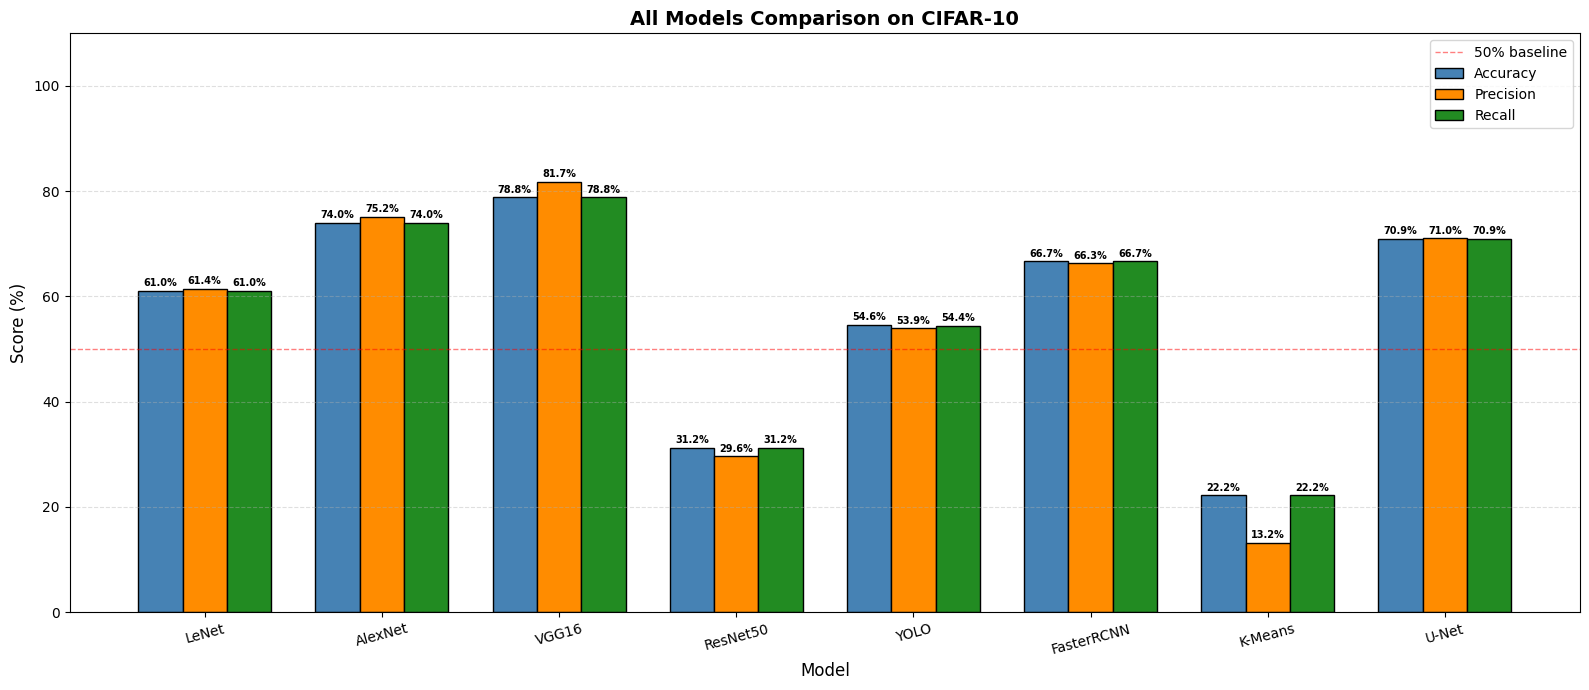

Model             Accuracy    Precision     Recall
LeNet               61.05%       61.44%     61.05%
AlexNet             73.99%       75.17%     73.99%
VGG16               78.81%       81.72%     78.81%
ResNet50            31.24%       29.58%     31.24%
YOLO                54.60%       53.93%     54.36%
FasterRCNN          66.65%       66.32%     66.65%
K-Means             22.18%       13.18%     22.18%
U-Net               70.91%       71.04%     70.91%


In [12]:
import matplotlib.pyplot as plt
import numpy as np

models    = ['LeNet', 'AlexNet', 'VGG16', 'ResNet50',
             'YOLO', 'FasterRCNN', 'K-Means', 'U-Net']
accuracy  = [61.05, 73.99, 78.81, 31.24, 54.60, 66.65, 22.18, 70.91]
precision = [61.44, 75.17, 81.72, 29.58, 53.93, 66.32, 13.18, 71.04]
recall    = [61.05, 73.99, 78.81, 31.24, 54.36, 66.65, 22.18, 70.91]

x     = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
b1 = ax.bar(x - width, accuracy,  width, label='Accuracy',  color='steelblue',   edgecolor='black')
b2 = ax.bar(x,         precision, width, label='Precision', color='darkorange',  edgecolor='black')
b3 = ax.bar(x + width, recall,    width, label='Recall',    color='forestgreen', edgecolor='black')

for bar in [*b1, *b2, *b3]:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

ax.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% baseline')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('All Models Comparison on CIFAR-10', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("=" * 70)
print(f"{'Model':<15} {'Accuracy':>10} {'Precision':>12} {'Recall':>10}")
print("=" * 70)
for i in range(len(models)):
    print(f"{models[i]:<15} {accuracy[i]:>9.2f}% {precision[i]:>11.2f}% {recall[i]:>9.2f}%")
print("=" * 70)